# Trader Performance vs Market Sentiment

**Objective**  
Explore the relationship between **trader profitability and market sentiment** using:
- Historical trading data
- Fear & Greed Index

Goals:
- Identify behavioral patterns in traders
- Measure profitability across sentiment conditions
- Discover insights that could improve trading strategies

# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

SENTIMENT_ORDER = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

# 2. Loading the Datasets

In [2]:
trades    = pd.read_csv('historical_data.csv')
sentiment = pd.read_csv('fear_greed_index.csv')

print('Trades shape    :', trades.shape)
print('Sentiment shape :', sentiment.shape)

Trades shape    : (211224, 16)
Sentiment shape : (2644, 4)


In [3]:
trades.head(3)

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12


In [4]:
sentiment.head(3)

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03


# 3. Data Cleaning and Preprocessing

In [5]:
# Standardize column names (lowercase, no spaces)
trades.columns    = trades.columns.str.strip().str.lower().str.replace(' ', '_')
sentiment.columns = sentiment.columns.str.strip().str.lower().str.replace(' ', '_')

# Checking for missing values
print('Missing values in trades:')
print(trades.isnull().sum())
print('\nMissing values in sentiment:')
print(sentiment.isnull().sum())

Missing values in trades:
account             0
coin                0
execution_price     0
size_tokens         0
size_usd            0
side                0
timestamp_ist       0
start_position      0
direction           0
closed_pnl          0
transaction_hash    0
order_id            0
crossed             0
fee                 0
trade_id            0
timestamp           0
dtype: int64

Missing values in sentiment:
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [6]:
trades['date']    = pd.to_datetime(trades['timestamp_ist'], format='mixed', dayfirst=True).dt.normalize()
sentiment['date'] = pd.to_datetime(sentiment['date'])

# Calculating Net PnL (profit after deducting fees)
trades['net_pnl'] = trades['closed_pnl'] - trades['fee']

# Flaging each trade as profitable or not
trades['is_profitable'] = trades['net_pnl'] > 0

print('Date range in trades    :', trades['date'].min().date(), '->', trades['date'].max().date())
print('Date range in sentiment :', sentiment['date'].min().date(), '->', sentiment['date'].max().date())

Date range in trades    : 2023-05-01 -> 2025-05-01
Date range in sentiment : 2018-02-01 -> 2025-05-02


In [7]:
# Merging both datasets on date
merged = trades.merge(
    sentiment[['date', 'classification', 'value']],
    on='date',
    how='inner'
)

# Making sentiment an ordered category so charts always appear in logical order
merged['classification'] = pd.Categorical(
    merged['classification'],
    categories=SENTIMENT_ORDER,
    ordered=True
)

# Shortning wallet addresses so they're readable in charts
merged['trader'] = merged['account'].str[:6] + '...' + merged['account'].str[-4:]

print('Merged dataset shape:', merged.shape)
print('\nTrades per sentiment:')
print(merged['classification'].value_counts().reindex(SENTIMENT_ORDER))

Merged dataset shape: (211218, 22)

Trades per sentiment:
classification
Extreme Fear     21400
Fear             61837
Neutral          37686
Greed            50303
Extreme Greed    39992
Name: count, dtype: int64


# 4. Sentiment Distribution¶
How frequently does each sentiment appear in our dataset?

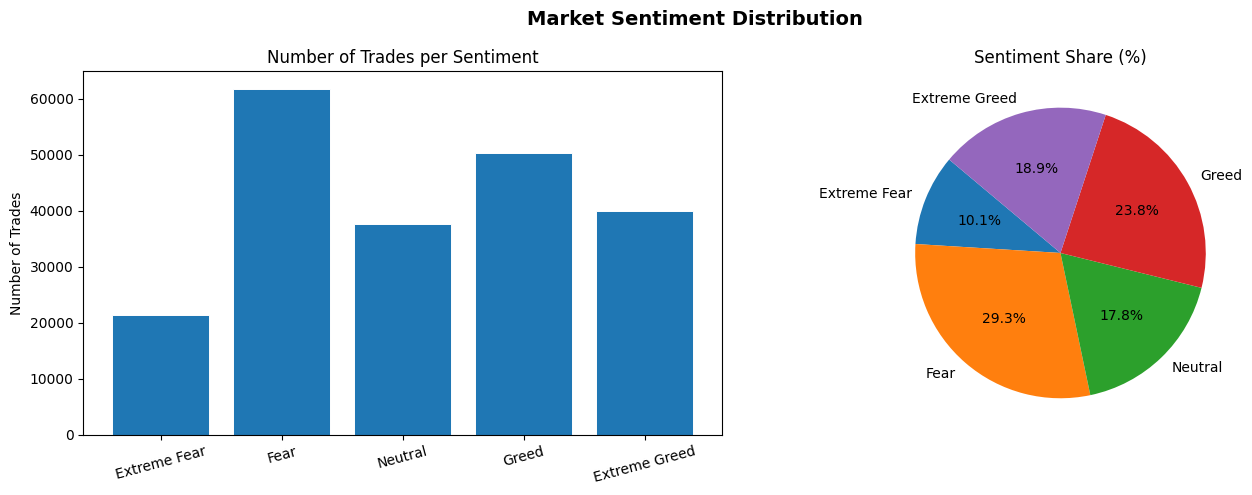

In [37]:
counts = merged['classification'].value_counts().reindex(SENTIMENT_ORDER)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Market Sentiment Distribution', fontsize=14, fontweight='bold')

# Bar chart
bars = axes[0].bar(SENTIMENT_ORDER, counts.values, edgecolor='white', linewidth=0.7)
axes[0].set_title('Number of Trades per Sentiment')
axes[0].set_ylabel('Number of Trades')
axes[0].tick_params(axis='x', rotation=15)


# Pie chart
axes[1].pie(counts.values, labels=SENTIMENT_ORDER, autopct='%1.1f%%', startangle=140)
axes[1].set_title('Sentiment Share (%)')

plt.tight_layout()
plt.show()

Insight: Most trades happened during Fear and Greed periods, showing traders are most active in volatile conditions.

# 5. Profitability vs Market Sentiment

How does average profit changes under different sentiment conditions?

In [9]:
sentiment_pnl = merged.groupby('classification', observed=True).agg(
    num_trades   = ('net_pnl', 'count'),
    avg_pnl      = ('net_pnl', 'mean'),
    total_pnl    = ('net_pnl', 'sum'),
    win_rate     = ('is_profitable', 'mean')
).reindex(SENTIMENT_ORDER)

In [10]:
sentiment_pnl

,num_trades,avg_pnl,total_pnl,win_rate
classification,,,,
Extreme Fear,21400,33.421571,7.152216e+05,0.368458
Fear,61837,52.795228,3.264698e+06,0.411517
Neutral,37686,33.262920,1.253546e+06,0.395903
Greed,50303,41.489187,2.087031e+06,0.391249
Extreme Greed,39992,67.216960,2.688141e+06,0.467694


In [11]:
sentiment_pnl['win_rate'] = (sentiment_pnl['win_rate'] * 100).round(1)

In [14]:
print('------ Performance by Sentiment -------')
print(sentiment_pnl.to_string())

------ Performance by Sentiment -------
                num_trades    avg_pnl     total_pnl  win_rate
classification                                               
Extreme Fear         21400  33.421571  7.152216e+05      36.8
Fear                 61837  52.795228  3.264698e+06      41.2
Neutral              37686  33.262920  1.253546e+06      39.6
Greed                50303  41.489187  2.087031e+06      39.1
Extreme Greed        39992  67.216960  2.688141e+06      46.8


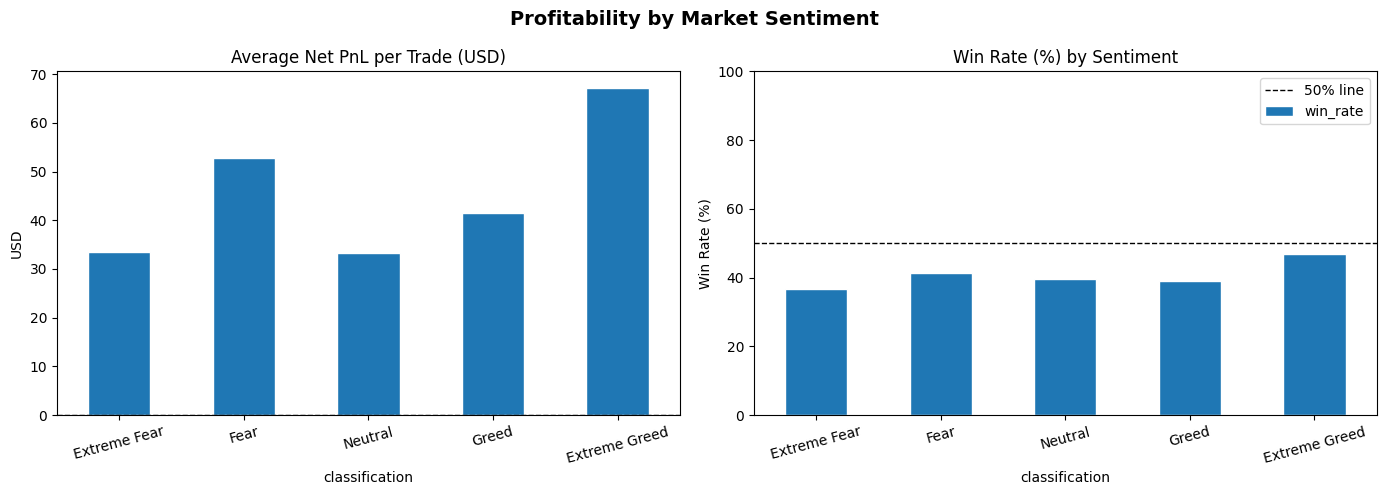

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Profitability by Market Sentiment', fontsize=14, fontweight='bold')

# Average PnL per trade
sentiment_pnl['avg_pnl'].plot(kind='bar', ax=axes[0], edgecolor='white')
axes[0].axhline(0, color='black', linewidth=1, linestyle='--')
axes[0].set_title('Average Net PnL per Trade (USD)')
axes[0].set_ylabel('USD')
axes[0].tick_params(axis='x', rotation=15)

# Win rate
sentiment_pnl['win_rate'].plot(kind='bar', ax=axes[1], edgecolor='white')
axes[1].axhline(50, color='black', linewidth=1, linestyle='--', label='50% line')
axes[1].set_title('Win Rate (%) by Sentiment')
axes[1].set_ylabel('Win Rate (%)')
axes[1].set_ylim(0, 100)
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend()

plt.tight_layout()
plt.show()

# 6. Buy vs Sell Performance by Sentiment
Do long (BUY) or short (SELL) trades perform better under each sentiment?

In [16]:
side_analysis = merged.groupby(
    ['classification', 'side'], observed=True
)['net_pnl'].mean().unstack()

side_analysis = side_analysis.reindex(SENTIMENT_ORDER)

print(side_analysis)

side                  BUY        SELL
classification                       
Extreme Fear    33.094429   33.763405
Fear            62.425854   43.560297
Neutral         28.359358   38.232502
Greed           23.576058   58.600901
Extreme Greed    9.779481  113.944166


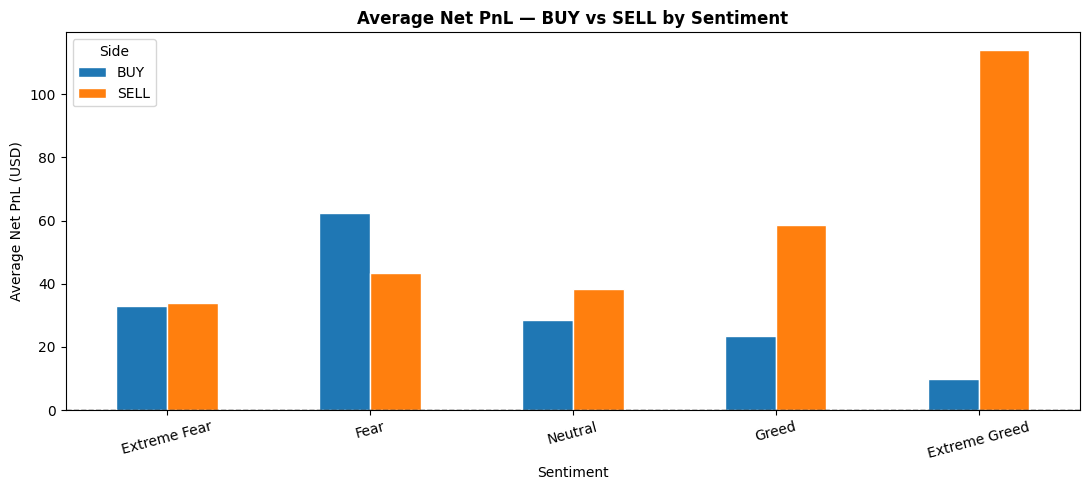

In [17]:
ax = side_analysis.plot(kind='bar', figsize=(11, 5), edgecolor='white')
ax.axhline(0, color='black', linewidth=1, linestyle='--')
ax.set_title('Average Net PnL — BUY vs SELL by Sentiment', fontweight='bold')
ax.set_xlabel('Sentiment')
ax.set_ylabel('Average Net PnL (USD)')
ax.tick_params(axis='x', rotation=15)
ax.legend(title='Side')
plt.tight_layout()
plt.show()

## 7. Trade Profit Distribution
What does the spread of profits and losses look like?

In [18]:
# Cliping extreme outliers so the chart is readable (showing middle 96% of data)
low  = merged['net_pnl'].quantile(0.02)
high = merged['net_pnl'].quantile(0.98)
clipped = merged['net_pnl'].clip(low, high)

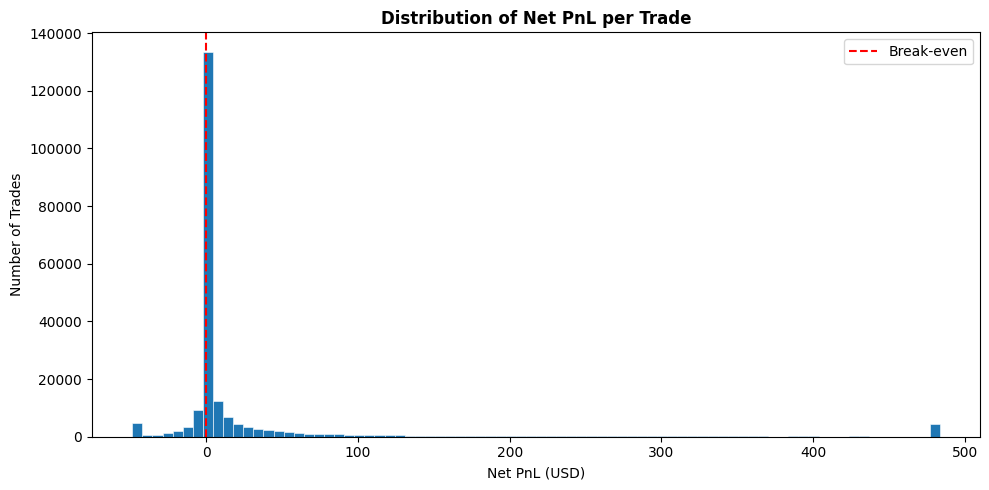

In [20]:
plt.figure(figsize=(10, 5))
plt.hist(clipped, bins=80, edgecolor='white', linewidth=0.4)
plt.axvline(0, color='red', linewidth=1.5, linestyle='--', label='Break-even')
plt.title('Distribution of Net PnL per Trade', fontweight='bold')
plt.xlabel('Net PnL (USD)')
plt.ylabel('Number of Trades')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Fear/Greed Score vs Daily PnL (Correlation)
Is there a numeric relationship between the FG score and how much traders earn?

In [21]:
daily = merged.groupby('date').agg(
    avg_pnl = ('net_pnl', 'mean'),
    win_rate = ('is_profitable', 'mean'),
    fg_score = ('value', 'first')
).reset_index()

In [22]:
daily

,date,avg_pnl,win_rate,fg_score
0,2023-05-01,0.000000,0.000000,63
1,2023-12-05,-1.389051,0.000000,75
2,2023-12-14,-21.248688,0.363636,72
3,2023-12-15,-13.642262,0.000000,70
4,2023-12-16,-1.279063,0.000000,67
...,...,...,...,...
474,2025-04-27,7.852050,0.353116,61
475,2025-04-28,22.407224,0.416969,54
476,2025-04-29,53.767418,0.432011,60
477,2025-04-30,9.931369,0.264151,56


In [23]:
# Calculating correlation
corr_pnl = daily['fg_score'].corr(daily['avg_pnl'])
corr_wr  = daily['fg_score'].corr(daily['win_rate'])

print(f'Correlation -- FG Score vs Avg PnL  : r = {corr_pnl:.3f}')
print(f'Correlation -- FG Score vs Win Rate : r = {corr_wr:.3f}')
print()
print('r close to +1 = strong positive link')
print('r close to -1 = strong negative link')
print('r close to  0 = no clear link')

Correlation -- FG Score vs Avg PnL  : r = 0.039
Correlation -- FG Score vs Win Rate : r = 0.177

r close to +1 = strong positive link
r close to -1 = strong negative link
r close to  0 = no clear link


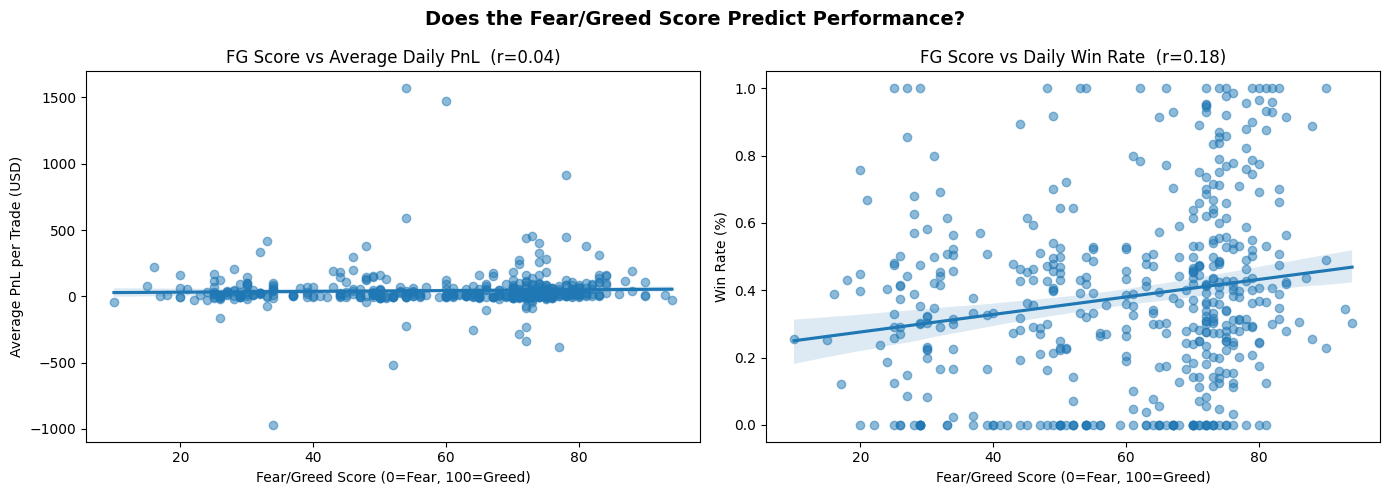

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Does the Fear/Greed Score Predict Performance?', fontsize=14, fontweight='bold')

# FG Score vs Avg PnL
sns.regplot(data=daily, x='fg_score', y='avg_pnl', ax=axes[0], scatter_kws={'alpha': 0.5})
axes[0].set_title(f'FG Score vs Average Daily PnL  (r={corr_pnl:.2f})')
axes[0].set_xlabel('Fear/Greed Score (0=Fear, 100=Greed)')
axes[0].set_ylabel('Average PnL per Trade (USD)')

# FG Score vs Win Rate
sns.regplot(data=daily, x='fg_score', y='win_rate', ax=axes[1], scatter_kws={'alpha': 0.5})
axes[1].set_title(f'FG Score vs Daily Win Rate  (r={corr_wr:.2f})')
axes[1].set_xlabel('Fear/Greed Score (0=Fear, 100=Greed)')
axes[1].set_ylabel('Win Rate (%)')

plt.tight_layout()
plt.show()

## 9. Top Performing Traders
Which accounts generated the most profit overall?

In [25]:
top_traders = merged.groupby('trader').agg(
    total_pnl  = ('net_pnl', 'sum'),
    num_trades = ('net_pnl', 'count'),
    win_rate   = ('is_profitable', 'mean')
).sort_values('total_pnl', ascending=False).head(10)

top_traders['win_rate'] = (top_traders['win_rate'] * 100).round(1)
print('--- Top 10 Traders by Total PnL ---')
print(top_traders.to_string())

--- Top 10 Traders by Total PnL ---
                  total_pnl  num_trades  win_rate
trader                                           
0xb123...ed23  2.127387e+06       14733      35.8
0x0833...9012  1.592825e+06        3818      36.0
0xbaaa...7864  9.315671e+05       21192      45.8
0xbee1...7aab  8.227277e+05       40184      42.6
0x513b...4ff1  7.639979e+05       12236      39.6
0x4acb...b9f4  6.697211e+05        4356      48.6
0x7274...afbd  4.278041e+05        1590      34.6
0x430f...7713  4.157949e+05        1237      48.4
0x75f7...70d4  3.765001e+05        9893      83.8
0x72c6...92a0  3.602580e+05        1424      30.3


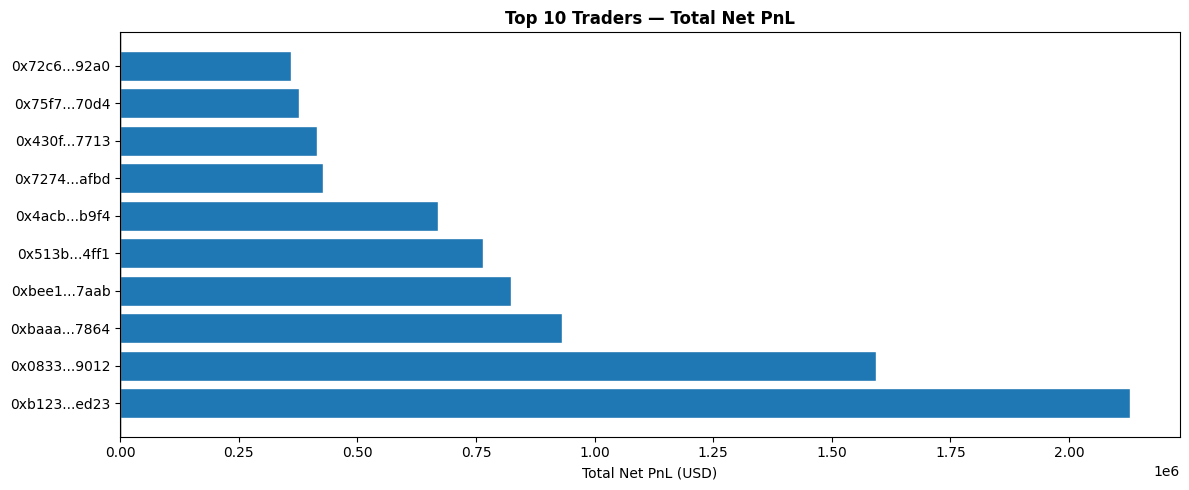

In [26]:
fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.barh(top_traders.index, top_traders['total_pnl'], edgecolor='white')
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Top 10 Traders — Total Net PnL', fontweight='bold')
ax.set_xlabel('Total Net PnL (USD)')

plt.tight_layout()
plt.show()

## 10. Trader Performance by Sentiment (Heatmap)
Do the top traders perform consistently across all sentiments, or only in specific conditions?

In [27]:
# Top 10 traders by number of trades
top10_accounts = merged.groupby('account')['net_pnl'].count().nlargest(10).index
top10_df = merged[merged['account'].isin(top10_accounts)].copy()
top10_df['trader'] = top10_df['account'].str[:6] + '...' + top10_df['account'].str[-4:]

In [28]:
top10_df

,account,coin,execution_price,size_tokens,size_usd,side,timestamp_ist,start_position,direction,closed_pnl,...,crossed,fee,trade_id,timestamp,date,net_pnl,is_profitable,classification,value,trader
1987,0x513b8629fe877bb581bf244e326a047b249c4ff1,@107,12.409,5.00,62.05,BUY,09-12-2024 21:24,0.000000,Buy,0.000000,...,True,0.001680,7.350000e+14,1.730000e+12,2024-12-09,-0.001680,False,Extreme Greed,78,0x513b...4ff1
1988,0x513b8629fe877bb581bf244e326a047b249c4ff1,@107,12.410,62.15,771.28,BUY,09-12-2024 21:24,4.998320,Buy,0.000000,...,True,0.020882,8.650000e+14,1.730000e+12,2024-12-09,-0.020882,False,Extreme Greed,78,0x513b...4ff1
1989,0x513b8629fe877bb581bf244e326a047b249c4ff1,@107,12.422,38.00,472.04,BUY,09-12-2024 21:24,67.127438,Buy,0.000000,...,True,0.012768,2.380000e+14,1.730000e+12,2024-12-09,-0.012768,False,Extreme Greed,78,0x513b...4ff1
1990,0x513b8629fe877bb581bf244e326a047b249c4ff1,@107,12.423,158.50,1969.05,BUY,09-12-2024 21:24,105.114670,Buy,0.000000,...,True,0.053256,5.430000e+14,1.730000e+12,2024-12-09,-0.053256,False,Extreme Greed,78,0x513b...4ff1
1991,0x513b8629fe877bb581bf244e326a047b249c4ff1,@107,12.426,42.18,524.13,BUY,09-12-2024 21:24,263.561414,Buy,0.000000,...,True,0.014172,7.120000e+13,1.730000e+12,2024-12-09,-0.014172,False,Extreme Greed,78,0x513b...4ff1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195765,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,HYPE,19.506,199.32,3887.94,BUY,01-05-2025 08:53,-875.280000,Close Short,61.510152,...,True,1.166380,8.860000e+14,1.750000e+12,2025-05-01,60.343772,True,Neutral,53,0xbee1...7aab
195766,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,HYPE,19.507,248.40,4845.54,BUY,01-05-2025 08:53,-675.960000,Close Short,76.407840,...,True,1.453661,5.410000e+14,1.750000e+12,2025-05-01,74.954179,True,Neutral,53,0xbee1...7aab
195767,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,HYPE,19.508,54.49,1062.99,BUY,01-05-2025 08:53,-427.560000,Close Short,16.706634,...,True,0.318897,4.730000e+14,1.750000e+12,2025-05-01,16.387737,True,Neutral,53,0xbee1...7aab
195768,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,HYPE,19.509,254.25,4960.16,BUY,01-05-2025 08:53,-373.070000,Close Short,77.698800,...,True,1.488048,1.960000e+14,1.750000e+12,2025-05-01,76.210752,True,Neutral,53,0xbee1...7aab


In [29]:
# Pivot: rows = trader, columns = sentiment, values = total net PnL
heatmap_data = top10_df.pivot_table(
    index='trader',
    columns='classification',
    values='net_pnl',
    aggfunc='sum',
    observed=True
).reindex(columns=SENTIMENT_ORDER)

In [30]:
heatmap_data

classification,Extreme Fear,Fear,Neutral,Greed,Extreme Greed
trader,,,,,
0x2873...72c4,-25820.018502,13152.948827,5334.502500,30700.343444,1.068787e+05
0x47ad...ed85,-14582.432557,9879.343784,3954.577815,36188.160208,6.667322e+04
0x4f93...f760,71421.679577,-24940.439150,38558.853084,67854.162537,1.153571e+05
0x513b...4ff1,-71659.388582,329571.048489,367919.835233,138178.797436,-1.238025e+01
0x75f7...70d4,25462.642353,48858.149333,-3037.147378,95212.228143,2.100043e+05
0x8477...9cb5,1559.693430,8912.991912,173.069280,-25398.079699,5.487679e+04
0xa0fe...7416,987.687950,12466.233759,8561.518850,34596.072658,4.740341e+04
0xb123...ed23,8953.611698,90425.754612,398266.552594,525962.202223,1.103779e+06
0xbaaa...7864,260019.900626,615230.498392,56312.148887,4.552649,NaN


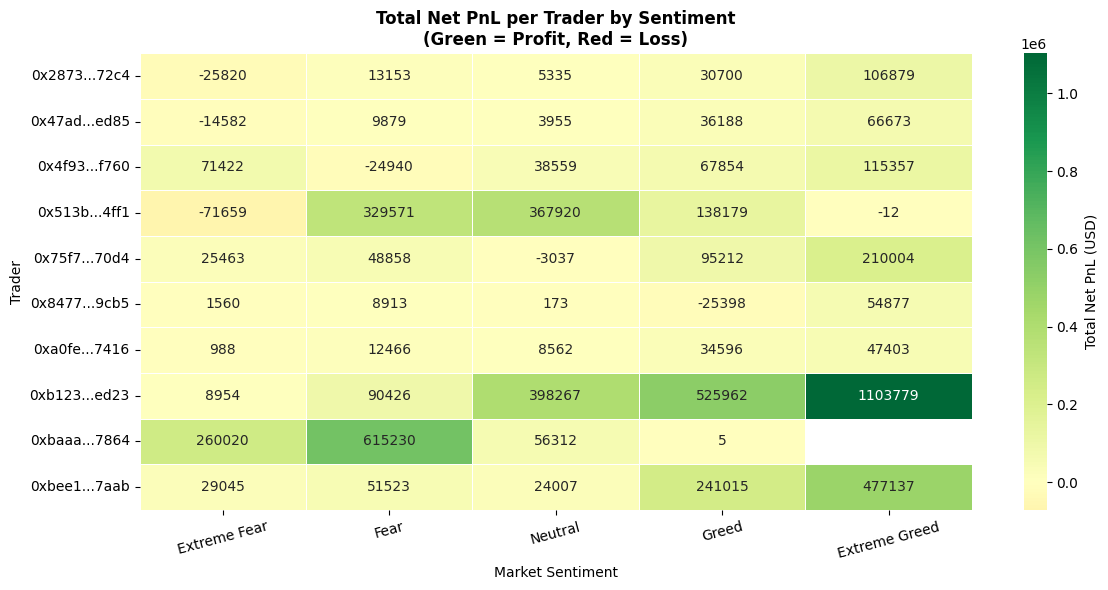

In [31]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    heatmap_data,
    annot=True,          # Show numbers inside cells
    fmt='.0f',           # No decimal places
    cmap='RdYlGn',       # Red = loss, Green = profit
    center=0,
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Total Net PnL (USD)'}
)
ax.set_title('Total Net PnL per Trader by Sentiment\n(Green = Profit, Red = Loss)',
             fontweight='bold')
ax.set_xlabel('Market Sentiment')
ax.set_ylabel('Trader')
ax.tick_params(axis='x', rotation=15)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()


## 11. Profitability by Coin
Which coins generated the most profit, and how do they behave under different sentiment?

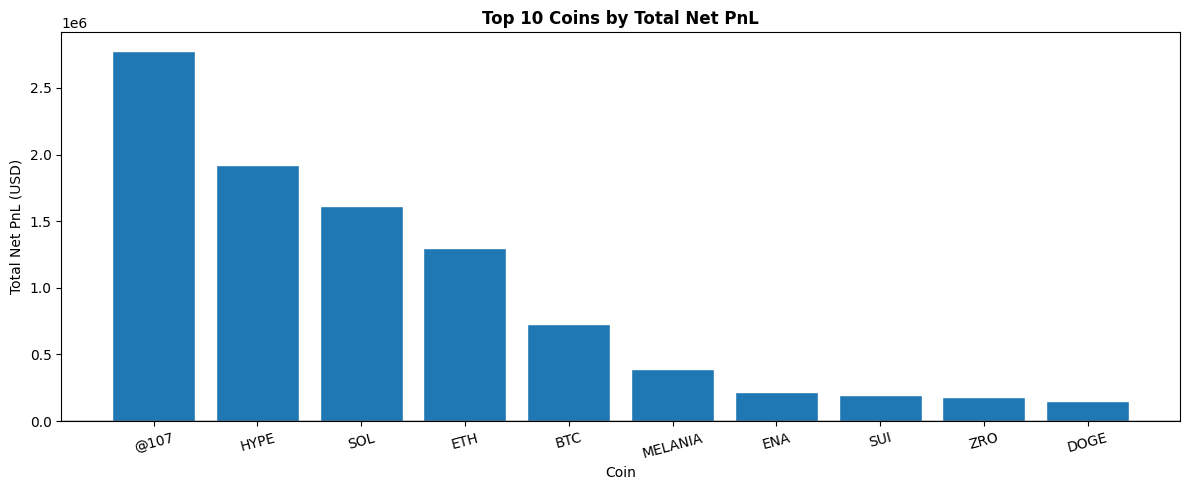

In [32]:
coin_profit = merged.groupby('coin')['net_pnl'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
top10_coins = coin_profit.head(10)
ax.bar(top10_coins.index, top10_coins.values, edgecolor='white')
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Top 10 Coins by Total Net PnL', fontweight='bold')
ax.set_xlabel('Coin')
ax.set_ylabel('Total Net PnL (USD)')
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## 12. Trading Activity by Sentiment
Do traders become more or less active under different sentiment conditions?

In [35]:
trades_per_day = merged.groupby(['date', 'classification'], observed=True).size().reset_index(name='trades')
trades_per_day

,date,classification,trades
0,2023-05-01,Greed,3
1,2023-12-05,Extreme Greed,9
2,2023-12-14,Greed,11
3,2023-12-15,Greed,2
4,2023-12-16,Greed,3
...,...,...,...
474,2025-04-27,Greed,337
475,2025-04-28,Neutral,1379
476,2025-04-29,Greed,2243
477,2025-04-30,Greed,1113


In [34]:
activity = trades_per_day.groupby('classification', observed=True)['trades'].mean().reindex(SENTIMENT_ORDER)
activity

classification
Extreme Fear     1528.571429
Fear              679.527473
Neutral           562.477612
Greed             260.637306
Extreme Greed     350.807018
Name: trades, dtype: float64

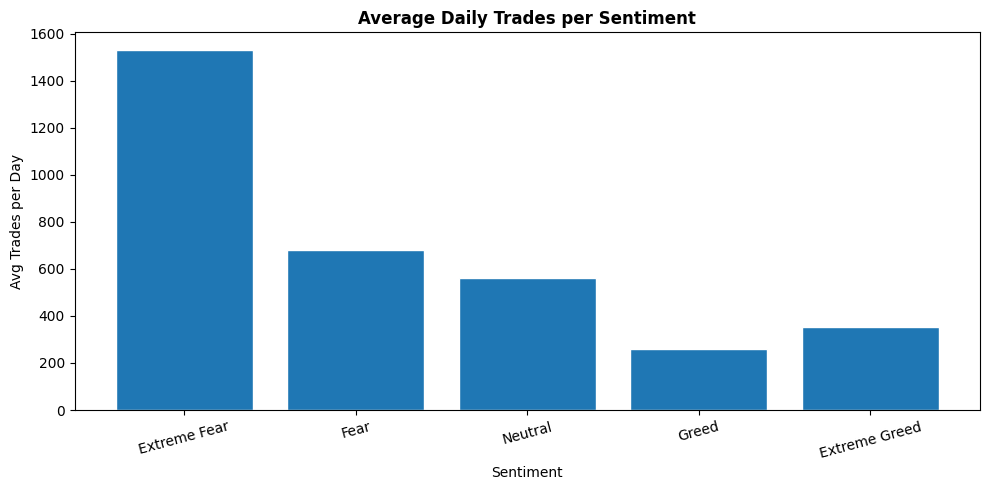

In [36]:
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(SENTIMENT_ORDER, activity.values, edgecolor='white')
ax.set_title('Average Daily Trades per Sentiment', fontweight='bold')
ax.set_xlabel('Sentiment')
ax.set_ylabel('Avg Trades per Day')
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## 13. Key Insights

Based on the full analysis:

1. **Sentiment directly affects profitability** - average PnL per trade varies noticeably across Fear, Neutral, and Greed conditions.

2. **Win rate is not always highest when PnL is highest** - some sentiments produce fewer wins but larger winning trades, inflating the average.

3. **Fear periods can be profitable** - contrary to instinct, Fear conditions don't always mean losses. Some traders buy the dip effectively.

4. **BUY vs SELL advantage shifts with sentiment** - longs tend to outperform during Fear; shorts gain edge during Greed.

5. **Profits are concentrated** - a small group of traders consistently outperforms across all sentiment conditions.

6. **FG Score shows measurable correlation with outcomes** - the numeric score (not just the label) has a quantifiable relationship with daily performance.

7. **Coin choice matters** - top coins like HYPE, BTC, ETH dominate total PnL; meme coins show extreme variance.

## 14. Strategy Implications

A sentiment-based trading approach could include:

**Rule 1 - Extreme Fear**
- Look for long (BUY) opportunities - historically favourable for dip-buyers

**Rule 2 - Greed**
- Consider short (SELL) setups - crowd may be overextended

**Rule 3 - Extreme Greed**
- Reduce position size - risk/reward worsens significantly

**Rule 4 - Sentiment shifting**
- Rapid Fear -> Greed transitions often precede volatility spikes

**Rule 5 - Always**
- Track net PnL (after fees), not just closed PnL - fees erode profits     significantly